# 03 — Predictive Experiment: Basket Completion via Association Graph

Evaluates three recommenders on the basket completion task:
- **Popularity**: context-unaware baseline (global product frequency)
- **LocalAgg**: average direct confidence weights from observed items
- **PPR**: Personalized PageRank over the confidence graph

**Task:** given a random subset of a test basket (observed items), recommend items to complete it.
Metrics are computed **only over products present in the training co-occurrence graph**.

**Prerequisite:** run `python scripts/run_experiment.py` to generate `outputs/results/`.

## 0. Setup

In [1]:
import sys, os, json
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, wilcoxon

from src.graph_builder import load_graph

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

RESULTS_PATH   = '../outputs/results/experiment_results_merged.parquet'
HIT_RATES_PATH = '../outputs/results/product_hit_rates_merged.parquet'
GRAPH_DIR      = '../outputs/graphs'
TEST_DATA      = '../data/processed/test.parquet'
PARAMS_PATH    = '../outputs/results/params_merged.json'

METHOD_LABELS = {'popularity': 'Popularity', 'local_agg': 'LocalAgg', 'ppr': 'PPR'}
METHOD_ORDER  = ['popularity', 'local_agg', 'ppr']

N_OBS_FRACTIONS = [0.25, 0.5, 0.75]
FRAC_LABELS     = {0.25: '25%', 0.5: '50%', 0.75: '75%'}
K_VALUES        = [5, 10, 20]

## 1. Load Results

In [2]:
with open(PARAMS_PATH) as f:
    params = json.load(f)
print('Experiment params:')
for key, val in params.items():
    print(f'  {key}: {val}')

results = pd.read_parquet(RESULTS_PATH)
print(f'\nShape: {results.shape}')
print(f'Methods:   {sorted(results["method"].unique())}')
print(f'n_obs:     {sorted(results["n_obs"].unique())}')
print(f'k values:  {sorted(results["k"].unique())}')
print(f'Baskets:   {results["basket_id"].nunique():,}')
results.head()

Experiment params:
  seed: 42
  min_cooccurrence: 2
  min_basket_size: 2
  max_basket_size: None
  n_obs: ['0.25', '0.5', '0.75']
  k_values: [5, 10, 20]
  n_repetitions: 10
  alpha: 0.85
  n_shards: 5
  n_workers: 4

Shape: (10534770, 7)
Methods:   ['local_agg', 'popularity', 'ppr']
n_obs:     [np.float64(0.25), np.float64(0.5), np.float64(0.75)]
k values:  [np.int64(5), np.int64(10), np.int64(20)]
Baskets:   45,229


,basket_id,n_obs,method,k,repetition,precision,recall
0,25,0.25,popularity,5,0,0.20,1.0
1,25,0.25,popularity,10,0,0.10,1.0
2,25,0.25,popularity,20,0,0.05,1.0
3,25,0.25,local_agg,5,0,0.00,0.0
4,25,0.25,local_agg,10,0,0.00,0.0


## 1b. Graph Coverage Diagnostic

Quantifica quantos produtos do conjunto de teste estão presentes no grafo de co-ocorrência.

> **Nota de interpretação:** todas as métricas deste notebook (Recall@k, Precision@k, F1@k) são
> calculadas **somente sobre produtos presentes no grafo**. Produtos do teste ausentes do grafo são
> excluídos do conjunto `hidden` e, portanto, não entram nem no numerador nem no denominador.
> O recall reportado é **recall condicional** — mais otimista do que o recall real sobre a cesta completa.

In [3]:
G = load_graph(GRAPH_DIR)
graph_products = set(G.nodes())

test_df = pd.read_parquet(TEST_DATA, columns=['basket_id', 'product_idx'])

all_test_products = set(test_df['product_idx'].unique())
in_graph          = all_test_products & graph_products
out_of_graph      = all_test_products - graph_products

print(f'Produtos únicos no teste:           {len(all_test_products):,}')
print(f'Presentes no grafo (avaliados):     {len(in_graph):,} ({100 * len(in_graph) / len(all_test_products):.1f}%)')
print(f'Ausentes do grafo (excluídos):      {len(out_of_graph):,} ({100 * len(out_of_graph) / len(all_test_products):.1f}%)')

basket_coverage = (
    test_df
    .assign(in_graph=test_df['product_idx'].isin(graph_products))
    .groupby('basket_id')['in_graph']
    .mean()
)
print(f'\nCobertura por cesta (fração dos itens no grafo):')
print(f'  Mediana: {basket_coverage.median():.1%}')
print(f'  Média:   {basket_coverage.mean():.1%}')
print(f'  Cestas com cobertura 100%:  {(basket_coverage == 1.0).sum():,} ({100 * (basket_coverage == 1.0).mean():.1f}%)')
print(f'  Cestas com cobertura < 50%: {(basket_coverage < 0.5).sum():,} ({100 * (basket_coverage < 0.5).mean():.1f}%)')

Produtos únicos no teste:           37,745
Presentes no grafo (avaliados):     26,710 (70.8%)
Ausentes do grafo (excluídos):      11,035 (29.2%)

Cobertura por cesta (fração dos itens no grafo):
  Mediana: 100.0%
  Média:   92.6%
  Cestas com cobertura 100%:  40,434 (68.4%)
  Cestas com cobertura < 50%: 1,758 (3.0%)


## 2. Distribution of Test Basket Sizes

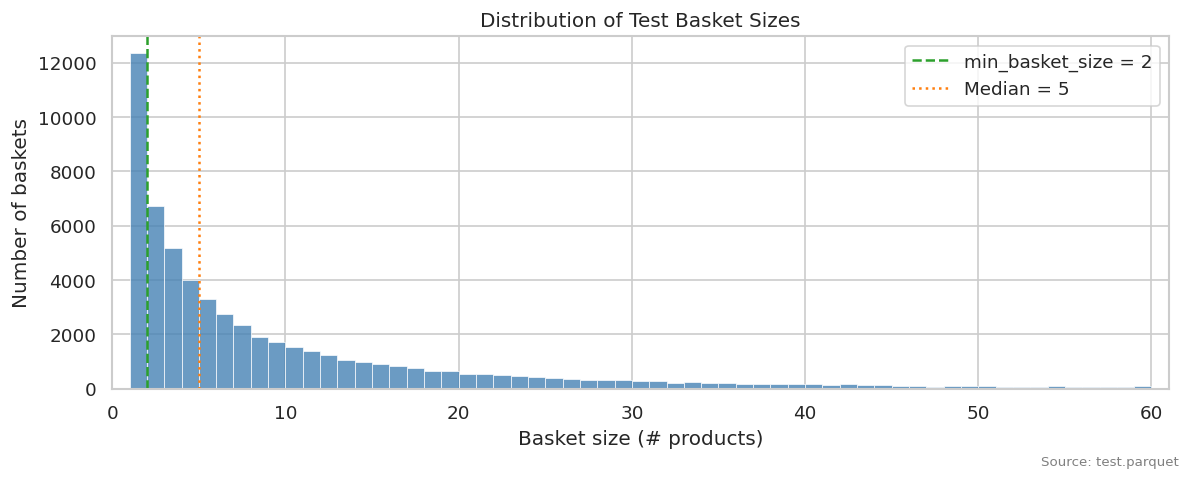

Total test baskets:              59,077
Evaluated (size 2–∞):  46,727 (79.1%)
Median size (all):               5
Median size (evaluated):         7


In [4]:
basket_sizes = test_df.groupby('basket_id')['product_idx'].count()

min_bs = params.get('min_basket_size', 2)
max_bs = params.get('max_basket_size', None)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(basket_sizes, bins=range(1, min(100, int(basket_sizes.quantile(0.99))) + 2),
        edgecolor='white', linewidth=0.5, color='steelblue', alpha=0.8)
ax.axvline(min_bs, color='tab:green', linestyle='--', linewidth=1.5,
           label=f'min_basket_size = {min_bs}')
if max_bs:
    ax.axvline(max_bs, color='tab:red', linestyle='--', linewidth=1.5,
               label=f'max_basket_size = {max_bs}')
ax.axvline(basket_sizes.median(), color='tab:orange', linestyle=':', linewidth=1.5,
           label=f'Median = {basket_sizes.median():.0f}')
ax.set_xlabel('Basket size (# products)')
ax.set_ylabel('Number of baskets')
ax.set_title('Distribution of Test Basket Sizes')
ax.set_xlim(0, max(50, int(basket_sizes.quantile(0.99)) + 2))
ax.legend()
fig.text(0.99, 0.01, 'Source: test.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

eligible = basket_sizes[
    (basket_sizes >= min_bs) & (basket_sizes <= (max_bs if max_bs else float('inf')))
]
print(f'Total test baskets:              {len(basket_sizes):,}')
print(f'Evaluated (size {min_bs}–{max_bs or "∞"}):  {len(eligible):,} ({100 * len(eligible) / len(basket_sizes):.1f}%)')
print(f'Median size (all):               {basket_sizes.median():.0f}')
print(f'Median size (evaluated):         {eligible.median():.0f}')

## 3. Summary Table: Precision, Recall & F1 at n_obs = 50%

Agregação em dois níveis: média sobre repetições por cesta → média sobre cestas.
F1 = 2·P·R / (P+R); quando P=R=0, F1=0 (cestas sem nenhum hit contam na média com zero).

In [5]:
# Per-basket means (averaged over repetitions) for all n_obs — reused in later sections
per_basket_all = (
    results
    .groupby(['basket_id', 'n_obs', 'method', 'k'])[['precision', 'recall']]
    .mean()
    .reset_index()
)

# F1 fix: P=R=0 → F1=0 (not NaN).
# Using NaN *excludes* those baskets from the mean, creating a selection bias that inflates
# aggregate F1 and can invert the method ranking (e.g., Popularity > LocalAgg in old F1@5
# at n_obs=25% even though LocalAgg dominates both P and R).
denom = per_basket_all['precision'] + per_basket_all['recall']
per_basket_all['f1'] = np.where(
    denom == 0, 0.0,
    2 * per_basket_all['precision'] * per_basket_all['recall'] / denom.replace(0, np.nan),
)

# Diagnostic: fraction of baskets with P=R=0 (previously excluded, now F1=0)
zero_frac = (
    (denom == 0)
    .groupby([per_basket_all['n_obs'], per_basket_all['method'], per_basket_all['k']])
    .mean()
    .unstack('method')
    .xs(5, level='k')
    .rename(columns=METHOD_LABELS)
    [[METHOD_LABELS[m] for m in METHOD_ORDER]]
    .round(3)
)
zero_frac.index = zero_frac.index.map(FRAC_LABELS)
print('Fraction of baskets with P=R=0 at k=5 (were excluded from F1 mean, now counted as F1=0):')
display(zero_frac)
print('→ Popularity excludia ~67–72% das cestas; LocalAgg ~48–54%. '
      'O fillna(0) garante que o F1 médio reflita o desempenho sobre todas as cestas.')

ref_frac   = 0.5
per_basket = per_basket_all[per_basket_all['n_obs'] == ref_frac]

summary = (
    per_basket
    .groupby(['method', 'k'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
)
summary.index = summary.index.set_levels(
    [METHOD_LABELS.get(m, m) for m in summary.index.get_level_values('method').unique()],
    level='method',
)
summary = summary.reindex(
    pd.MultiIndex.from_product(
        [[METHOD_LABELS[m] for m in METHOD_ORDER], K_VALUES],
        names=['method', 'k'],
    )
)
print('\nMean Precision, Recall & F1 across baskets at n_obs = 50%')
display(summary)

Fraction of baskets with P=R=0 at k=5 (were excluded from F1 mean, now counted as F1=0):


method,Popularity,LocalAgg,PPR
n_obs,,,
25%,0.715,0.480,0.625
50%,0.680,0.492,0.615
75%,0.671,0.541,0.628


→ Popularity excludia ~67–72% das cestas; LocalAgg ~48–54%. O fillna(0) garante que o F1 médio reflita o desempenho sobre todas as cestas.

Mean Precision, Recall & F1 across baskets at n_obs = 50%


precision  recall      f1
method     k                            
Popularity 5      0.0373  0.0330  0.0292
           10     0.0261  0.0455  0.0281
           20     0.0191  0.0636  0.0256
LocalAgg   5      0.0618  0.0641  0.0523
           10     0.0470  0.0947  0.0531
           20     0.0348  0.1336  0.0483
PPR        5      0.0447  0.0422  0.0360
           10     0.0318  0.0599  0.0349
           20     0.0229  0.0839  0.0313

## 4. Complete Metrics: All Fractions × k × Method

In [6]:
grand = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])[['precision', 'recall', 'f1']]
    .mean()
    .round(4)
    .reset_index()
)
grand['method'] = grand['method'].map(METHOD_LABELS)
grand['n_obs']  = grand['n_obs'].map(FRAC_LABELS)

full_index = pd.MultiIndex.from_product(
    [[FRAC_LABELS[f] for f in N_OBS_FRACTIONS], [METHOD_LABELS[m] for m in METHOD_ORDER]],
    names=['n_obs', 'method'],
)
graph_cov = len(in_graph) / len(all_test_products)

for metric in ['precision', 'recall', 'f1']:
    pivot = grand.pivot_table(
        index=['n_obs', 'method'], columns='k', values=metric,
    ).reindex(full_index)

    if metric == 'recall':
        print(f'\nRECALL@k  (conditional — graph products only)')
        display(pivot)
        print(f'\nTRUE RECALL@k  (×{graph_cov:.3f} graph coverage — {100*(1-graph_cov):.1f}% of test products absent from graph)')
        display((pivot * graph_cov).round(4))
    else:
        print(f'\n{metric.upper()}@k')
        display(pivot)


PRECISION@k


k                     5       10      20
n_obs method                            
25%   Popularity  0.0482  0.0342  0.0248
      LocalAgg    0.0784  0.0589  0.0431
      PPR         0.0583  0.0415  0.0299
50%   Popularity  0.0373  0.0261  0.0191
      LocalAgg    0.0618  0.0470  0.0348
      PPR         0.0447  0.0318  0.0229
75%   Popularity  0.0199  0.0138  0.0102
      LocalAgg    0.0332  0.0251  0.0186
      PPR         0.0237  0.0167  0.0121


RECALL@k  (conditional — graph products only)


k                     5       10      20
n_obs method                            
25%   Popularity  0.0341  0.0467  0.0642
      LocalAgg    0.0652  0.0929  0.1263
      PPR         0.0451  0.0629  0.0873
50%   Popularity  0.0330  0.0455  0.0636
      LocalAgg    0.0641  0.0947  0.1336
      PPR         0.0422  0.0599  0.0839
75%   Popularity  0.0327  0.0452  0.0642
      LocalAgg    0.0630  0.0934  0.1337
      PPR         0.0410  0.0578  0.0817


TRUE RECALL@k  (×0.708 graph coverage — 29.2% of test products absent from graph)


k                     5       10      20
n_obs method                            
25%   Popularity  0.0241  0.0330  0.0454
      LocalAgg    0.0461  0.0657  0.0894
      PPR         0.0319  0.0445  0.0618
50%   Popularity  0.0234  0.0322  0.0450
      LocalAgg    0.0454  0.0670  0.0945
      PPR         0.0299  0.0424  0.0594
75%   Popularity  0.0231  0.0320  0.0454
      LocalAgg    0.0446  0.0661  0.0946
      PPR         0.0290  0.0409  0.0578


F1@k


k                     5       10      20
n_obs method                            
25%   Popularity  0.0317  0.0317  0.0297
      LocalAgg    0.0561  0.0576  0.0534
      PPR         0.0399  0.0397  0.0368
50%   Popularity  0.0292  0.0281  0.0256
      LocalAgg    0.0523  0.0531  0.0483
      PPR         0.0360  0.0349  0.0313
75%   Popularity  0.0212  0.0187  0.0161
      LocalAgg    0.0374  0.0351  0.0300
      PPR         0.0257  0.0228  0.0193

## 5. Recall@k vs Observed Fraction

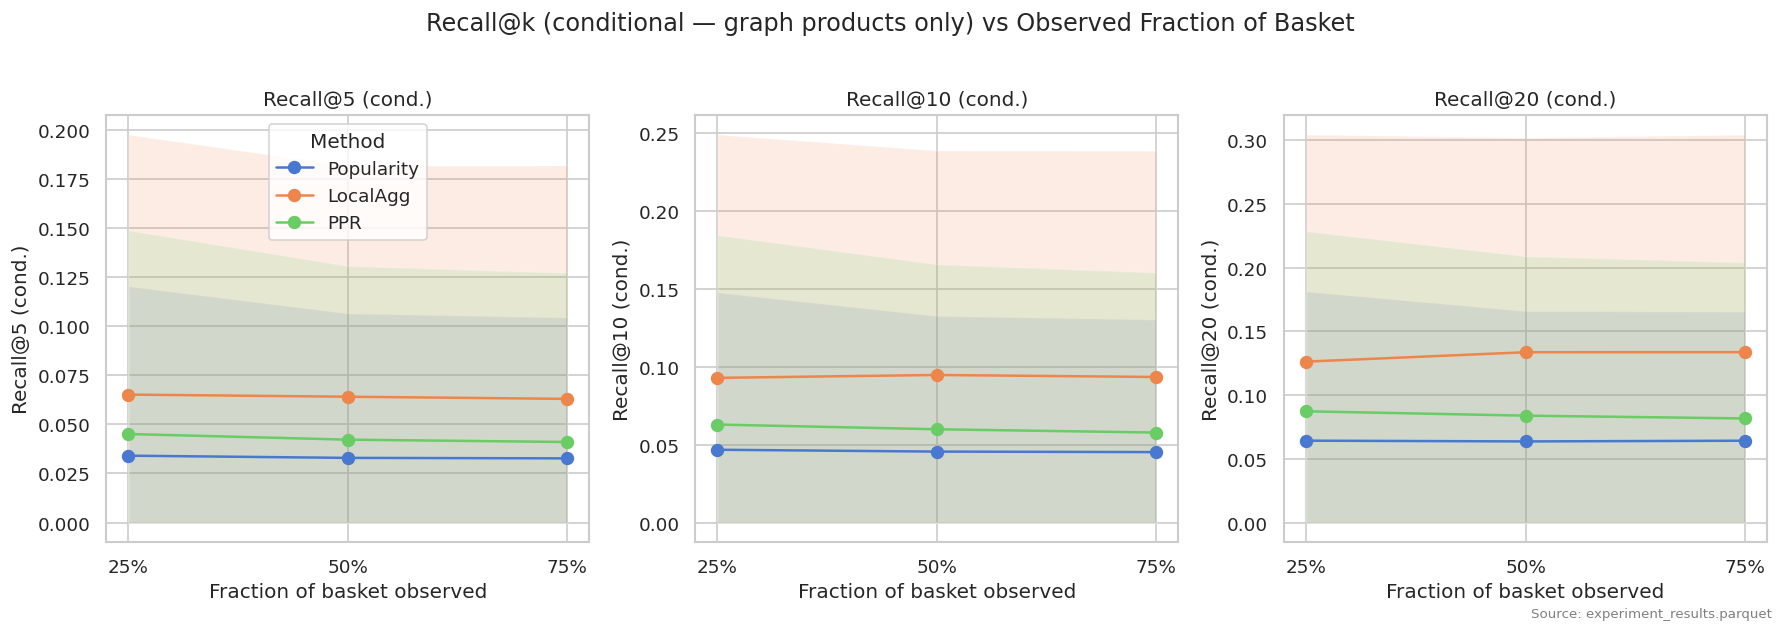

In [7]:
agg_recall = (
    per_basket_all
    .groupby(['n_obs', 'method', 'k'])['recall']
    .agg(['mean', 'std'])
    .reset_index()
)

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(5 * len(K_VALUES), 5), sharey=False)
for ax, k_val in zip(axes, K_VALUES):
    sub = agg_recall[agg_recall['k'] == k_val]
    for method in METHOD_ORDER:
        group = sub[sub['method'] == method].sort_values('n_obs')
        ax.plot(group['n_obs'], group['mean'], marker='o', markersize=7,
                label=METHOD_LABELS[method])
        ax.fill_between(
            group['n_obs'],
            (group['mean'] - group['std']).clip(lower=0),
            group['mean'] + group['std'],
            alpha=0.15,
        )
    ax.set_xticks(N_OBS_FRACTIONS)
    ax.set_xticklabels([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
    ax.set_xlabel('Fraction of basket observed')
    ax.set_ylabel(f'Recall@{k_val} (cond.)')
    ax.set_title(f'Recall@{k_val} (cond.)')
    if ax == axes[0]:
        ax.legend(title='Method')

fig.suptitle('Recall@k (conditional — graph products only) vs Observed Fraction of Basket', y=1.02)
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 5b. Recall Decomposed: Absolute Hits vs Hidden Set Size

O gráfico anterior mostra que o recall é quase **constante** entre 25% e 75% de observação —
resultado contra-intuitivo, pois com mais contexto esperaríamos recomendações melhores.

A decomposição abaixo mostra por quê: `recall = hits / |hidden|`.
Como `|hidden|` encolhe à medida que n_obs cresce, hits e denominador diminuem na mesma proporção.

> **Limitação do protocolo:** o Recall@k **não detecta se os métodos usam melhor o contexto adicional**.
> Para avaliar isso, seria necessário um denominador fixo (tamanho total da cesta) ou cestas com
> `|hidden|` constante. A métrica `basket_coverage@k` abaixo usa denominador fixo e evidencia essa
> limitação: os métodos não ganham eficiência com mais seeds — as recomendações absolutas diminuem
> na mesma proporção que o conjunto oculto.

> **Nota de implementação:** `basket_sizes` é re-indexado sequencialmente para corresponder aos IDs
> de cesta do experimento (gerados por `enumerate(groupby('basket_id'))` em `run_experiment.py`).

Decomposition of Recall@10 into absolute hits and hidden set size:


mean_n_hidden  mean_abs_hits  implied_recall
n_obs method                                                  
25%   Popularity          9.293          0.376          0.0405
      LocalAgg            9.293          0.658          0.0708
      PPR                 9.293          0.464          0.0499
50%   Popularity          7.091          0.286          0.0403
      LocalAgg            7.091          0.523          0.0738
      PPR                 7.091          0.353          0.0498
75%   Popularity          3.958          0.160          0.0404
      LocalAgg            3.958          0.296          0.0748
      PPR                 3.958          0.196          0.0495

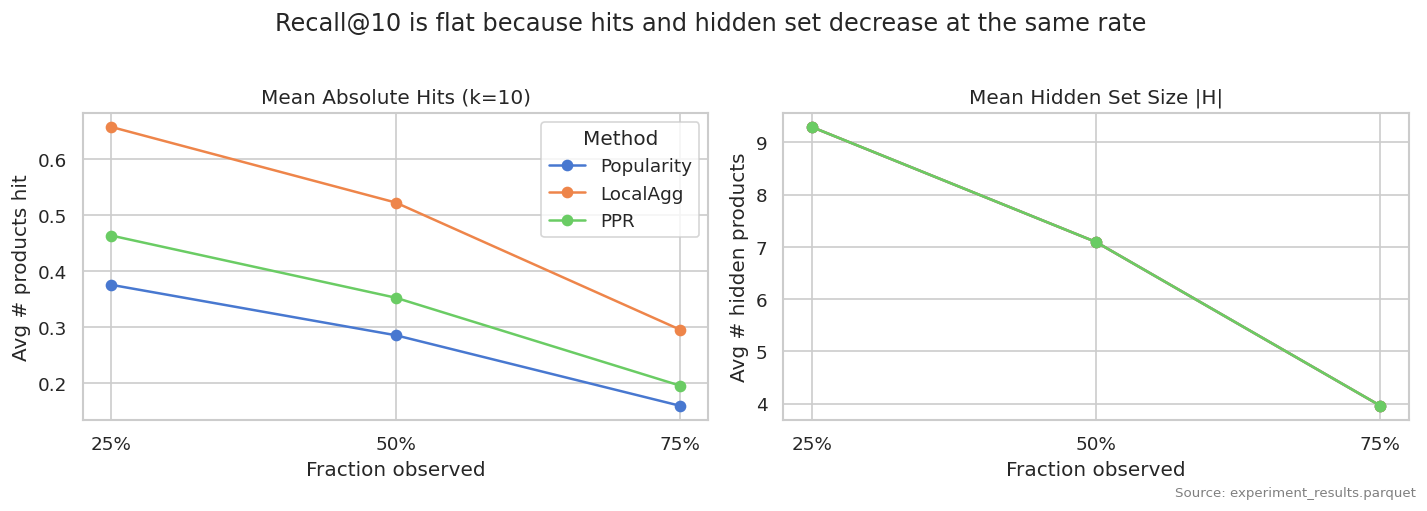

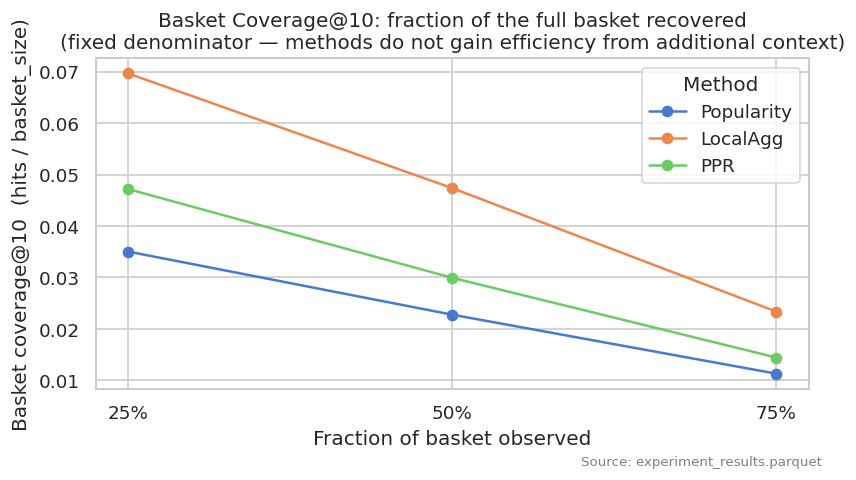


Basket Coverage@10 = hits / basket_size  (≈ conditional_recall × (1−n_obs)):


method,Popularity,LocalAgg,PPR
n_obs_label,,,
25%,0.0350,0.0697,0.0472
50%,0.0228,0.0474,0.0299
75%,0.0113,0.0234,0.0144



Merge sanity check: basket_id alignment is correct if decomp table has non-zero rows.
  Rows in merged_sizes: 351,159 (>0 confirms alignment)


In [8]:
# Re-index basket sizes to match the sequential basket_id used in experiment results.
# run_experiment.py loads baskets via enumerate(groupby('basket_id')), which sorts by basket_id.
basket_sizes_indexed = (
    test_df.groupby('basket_id')['product_idx']
    .count()
    .reset_index(drop=True)   # sequential 0, 1, 2, ... matching results['basket_id']
    .rename('basket_size')
    .rename_axis('basket_id')
    .reset_index()
)

k_ref = 10
merged_sizes = (
    per_basket_all[per_basket_all['k'] == k_ref]
    .merge(basket_sizes_indexed, on='basket_id')
)
merged_sizes['n_hidden'] = (merged_sizes['basket_size'] * (1 - merged_sizes['n_obs'])).clip(lower=1)
merged_sizes['abs_hits'] = merged_sizes['recall'] * merged_sizes['n_hidden']
# basket_coverage: hits / basket_size — fixed denominator, not inflated by shrinking hidden set
merged_sizes['basket_cov'] = merged_sizes['abs_hits'] / merged_sizes['basket_size']

decomp = (
    merged_sizes
    .groupby(['n_obs', 'method'])
    .agg(mean_abs_hits=('abs_hits', 'mean'), mean_n_hidden=('n_hidden', 'mean'))
    .round(3)
    .reset_index()
)
decomp['implied_recall'] = (decomp['mean_abs_hits'] / decomp['mean_n_hidden']).round(4)
decomp['n_obs'] = decomp['n_obs'].map(FRAC_LABELS)
decomp['method'] = decomp['method'].map(METHOD_LABELS)

print(f'Decomposition of Recall@{k_ref} into absolute hits and hidden set size:')
display(
    decomp.pivot_table(index=['n_obs', 'method'], values=['mean_abs_hits', 'mean_n_hidden', 'implied_recall'])
    .reindex(pd.MultiIndex.from_product(
        [[FRAC_LABELS[f] for f in N_OBS_FRACTIONS], [METHOD_LABELS[m] for m in METHOD_ORDER]],
        names=['n_obs', 'method']
    ))
    [['mean_n_hidden', 'mean_abs_hits', 'implied_recall']]
)

# --- Plot 1: abs_hits and n_hidden by n_obs ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for method in METHOD_ORDER:
    sub = decomp[decomp['method'] == METHOD_LABELS[method]]
    axes[0].plot(sub['n_obs'], sub['mean_abs_hits'], marker='o', label=METHOD_LABELS[method])
    axes[1].plot(sub['n_obs'], sub['mean_n_hidden'], marker='o', label=METHOD_LABELS[method])

axes[0].set_title(f'Mean Absolute Hits (k={k_ref})')
axes[0].set_xlabel('Fraction observed')
axes[0].set_ylabel('Avg # products hit')
axes[0].legend(title='Method')

axes[1].set_title('Mean Hidden Set Size |H|')
axes[1].set_xlabel('Fraction observed')
axes[1].set_ylabel('Avg # hidden products')

fig.suptitle(
    f'Recall@{k_ref} is flat because hits and hidden set decrease at the same rate',
    y=1.02,
)
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

# --- Plot 2: basket_coverage (fixed denominator) ---
# basket_cov@k = hits / basket_size = conditional_recall × (1 − n_obs)
# Unlike recall, denominator is the full basket size — not sensitive to how many items are hidden.
# Monotone decrease with n_obs confirms the methods do not recover proportionally more items
# as more context is provided: additional seeds do not translate into better recommendations.
cov_agg = (
    merged_sizes
    .groupby(['n_obs', 'method'])['basket_cov']
    .mean()
    .reset_index()
)
cov_agg['n_obs_label'] = cov_agg['n_obs'].map(FRAC_LABELS)

fig, ax = plt.subplots(figsize=(7, 4))
for method in METHOD_ORDER:
    sub = cov_agg[cov_agg['method'] == method].sort_values('n_obs')
    ax.plot(sub['n_obs_label'], sub['basket_cov'], marker='o', label=METHOD_LABELS[method])
ax.set_xlabel('Fraction of basket observed')
ax.set_ylabel(f'Basket coverage@{k_ref}  (hits / basket_size)')
ax.set_title(
    f'Basket Coverage@{k_ref}: fraction of the full basket recovered\n'
    f'(fixed denominator — methods do not gain efficiency from additional context)'
)
ax.legend(title='Method')
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print(f'\nBasket Coverage@{k_ref} = hits / basket_size  (≈ conditional_recall × (1−n_obs)):')
display(
    cov_agg.pivot_table(index='n_obs_label', columns='method', values='basket_cov')
    .rename(columns=METHOD_LABELS)
    .reindex([FRAC_LABELS[f] for f in N_OBS_FRACTIONS])
    [[METHOD_LABELS[m] for m in METHOD_ORDER]]
    .round(4)
)
print('\nMerge sanity check: basket_id alignment is correct if decomp table has non-zero rows.')
print(f'  Rows in merged_sizes: {len(merged_sizes):,} (>0 confirms alignment)')

## 7. Statistical Significance — Wilcoxon Signed-Rank Test

Testa se as diferenças de Recall@k entre pares de métodos são estatisticamente significativas.
Teste emparelhado por `basket_id`, unilateral (H_1: método A > método B).

> **Atenção:** com ~45 mil cestas, o poder estatístico é extremo. Qualquer diferença de recall > 0.001
> resulta em p próximo de 0. Os p-valores confirmam existência de efeito, mas **não sua magnitude nem
> relevância prática**. Leia os resultados pela coluna `mean_Δrecall` (tamanho de efeito), não pelo p-valor.

In [9]:
pairs = [
    ('local_agg', 'popularity', 'LocalAgg > Popularity'),
    ('ppr',       'popularity', 'PPR > Popularity'),
    ('local_agg', 'ppr',        'LocalAgg > PPR'),
]

rows = []
for n_obs_val in sorted(results['n_obs'].unique()):
    sub_n = per_basket_all[per_basket_all['n_obs'] == n_obs_val]
    for k_val in K_VALUES:
        wide = (
            sub_n[sub_n['k'] == k_val]
            .pivot(index='basket_id', columns='method', values='recall')
            .dropna()
        )
        for m1, m2, label in pairs:
            if m1 not in wide.columns or m2 not in wide.columns:
                continue
            d = wide[m1] - wide[m2]
            nonzero = d[d != 0]
            pct_nonzero = len(nonzero) / len(d)
            pval = wilcoxon(nonzero, alternative='greater').pvalue if len(nonzero) >= 20 else np.nan
            rows.append({
                'n_obs':        FRAC_LABELS[n_obs_val],
                'k':            k_val,
                'comparison':   label,
                'mean_Δrecall': round(d.mean(), 5),
                'pct_nonzero':  round(pct_nonzero, 3),
                'p_value':      round(pval, 6) if not np.isnan(pval) else np.nan,
                'sig':          bool(pval < 0.05) if not np.isnan(pval) else False,
            })

sig_df = pd.DataFrame(rows)

n_obs_order = [FRAC_LABELS[f] for f in N_OBS_FRACTIONS]

# Primary: effect size (mean_Δrecall pivot)
for _, _, label in pairs:
    sub = sig_df[sig_df['comparison'] == label]
    pivot_delta = sub.pivot_table(index='n_obs', columns='k', values='mean_Δrecall').reindex(n_obs_order)
    pivot_pval  = sub.pivot_table(index='n_obs', columns='k', values='p_value').reindex(n_obs_order)
    pivot_nz    = sub.pivot_table(index='n_obs', columns='k', values='pct_nonzero').reindex(n_obs_order)
    print(f'\n── {label} ──')
    print('mean_Δrecall (primary — practical effect size):')
    display(pivot_delta.round(5))
    print('fraction of baskets with Δrecall ≠ 0 (pairs that drive the test):')
    display(pivot_nz.round(3))
    print('p-value (secondary — n=45k makes almost any Δ significant):')
    display(pivot_pval.round(6))

print('\nAll comparisons significant (p < 0.05):', sig_df['sig'].all())
print('\nKey: mean_Δrecall is what matters operationally.')
print('     p ≈ 0 for all pairs is expected with n ≈ 45k — it confirms direction, not magnitude.')


── LocalAgg > Popularity ──
mean_Δrecall (primary — practical effect size):


k,5,10,20
n_obs,,,
25%,0.03115,0.04615,0.06202
50%,0.03119,0.04920,0.06999
75%,0.03032,0.04824,0.06952


fraction of baskets with Δrecall ≠ 0 (pairs that drive the test):


k,5,10,20
n_obs,,,
25%,0.437,0.531,0.607
50%,0.365,0.469,0.571
75%,0.258,0.363,0.468


p-value (secondary — n=45k makes almost any Δ significant):


...

fraction of baskets with Δrecall ≠ 0 (pairs that drive the test):


k,5,10,20
n_obs,,,
25%,0.393,0.476,0.551
50%,0.325,0.419,0.518
75%,0.217,0.305,0.404


p-value (secondary — n=45k makes almost any Δ significant):


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0



All comparisons significant (p < 0.05): True

Key: mean_Δrecall is what matters operationally.
     p ≈ 0 for all pairs is expected with n ≈ 45k — it confirms direction, not magnitude.


## 8. Recall by Basket Size Group

Desempenho estratificado por tamanho da cesta. Cestas pequenas têm recall muito variável
(denominador ≤ 3 itens), podendo mascarar ou amplificar diferenças entre métodos na média global.

> **Nota de implementação:** os IDs de cesta nos resultados do experimento são índices sequenciais
> (0, 1, 2, …) gerados por `enumerate(groupby('basket_id'))` em `run_experiment.py`. O merge com
> `basket_sizes` usa `basket_sizes_indexed` (criado na seção 5b) que já mapeia os tamanhos ao
> índice correto. A versão anterior usava os IDs reais do dataset, produzindo merge vazio e
> um gráfico silenciosamente em branco.

/tmp/ipykernel_56490/2804241389.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['size_group', 'n_obs', 'method', 'k'])['recall']


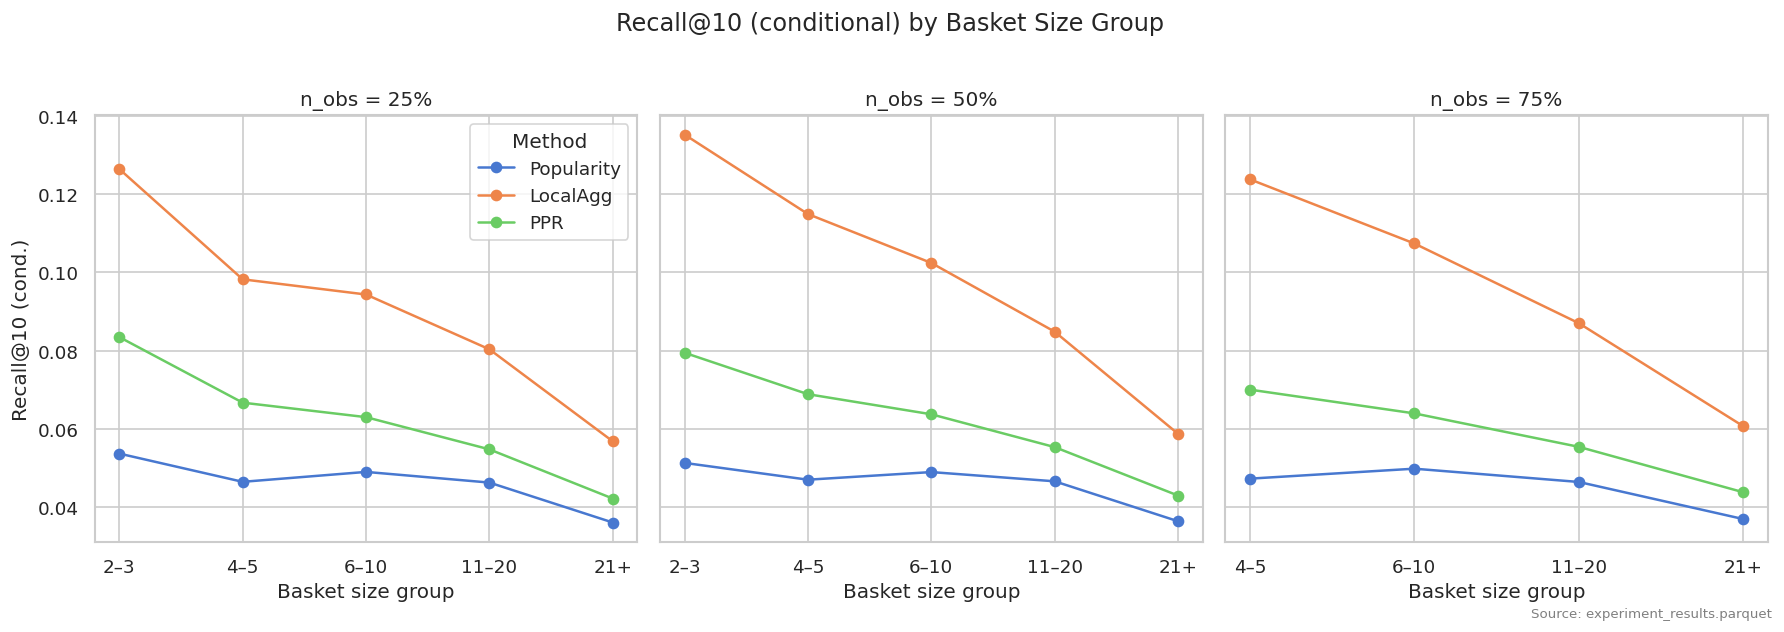

Baskets per size group:
  2–3: 11,928
  4–5: 7,306
  6–10: 10,297
  11–20: 9,015
  21+: 8,181

Merge sanity check: 135 rows in strat (>0 confirms basket_id alignment is correct)


In [10]:
size_bins   = [1, 3, 5, 10, 20, int(basket_sizes_indexed['basket_size'].max()) + 1]
size_labels = ['2–3', '4–5', '6–10', '11–20', '21+']

# Use basket_sizes_indexed (sequential IDs from section 5b) to correctly match experiment results
basket_size_df = basket_sizes_indexed.copy()
basket_size_df['size_group'] = pd.cut(
    basket_size_df['basket_size'], bins=size_bins, labels=size_labels, right=True
)

strat = (
    per_basket_all
    .merge(basket_size_df[['basket_id', 'size_group']], on='basket_id')
    .groupby(['size_group', 'n_obs', 'method', 'k'])['recall']
    .mean()
    .reset_index()
)

k_ref = 10
fig, axes = plt.subplots(1, len(N_OBS_FRACTIONS), figsize=(5 * len(N_OBS_FRACTIONS), 5), sharey=True)
for ax, n_obs_val in zip(axes, N_OBS_FRACTIONS):
    sub = strat[(strat['k'] == k_ref) & (strat['n_obs'] == n_obs_val)]
    for method in METHOD_ORDER:
        grp = sub[sub['method'] == method].sort_values('size_group')
        ax.plot(grp['size_group'].astype(str), grp['recall'],
                marker='o', label=METHOD_LABELS[method])
    ax.set_xlabel('Basket size group')
    ax.set_ylabel(f'Recall@{k_ref} (cond.)' if ax == axes[0] else '')
    ax.set_title(f'n_obs = {FRAC_LABELS[n_obs_val]}')
    if ax == axes[0]:
        ax.legend(title='Method')

fig.suptitle(f'Recall@{k_ref} (conditional) by Basket Size Group', y=1.02)
fig.text(0.99, 0.01, 'Source: experiment_results.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

counts = basket_size_df['size_group'].value_counts().sort_index()
print('Baskets per size group:')
for grp, cnt in counts.items():
    print(f'  {grp}: {cnt:,}')
print(f'\nMerge sanity check: {len(strat):,} rows in strat (>0 confirms basket_id alignment is correct)')

In [11]:
pairs = [
    ('local_agg', 'popularity', 'LocalAgg > Popularity'),
    ('ppr',       'popularity', 'PPR > Popularity'),
    ('local_agg', 'ppr',        'LocalAgg > PPR'),
]

rows = []
for n_obs_val in sorted(results['n_obs'].unique()):
    sub_n = per_basket_all[per_basket_all['n_obs'] == n_obs_val]
    for k_val in K_VALUES:
        wide = (
            sub_n[sub_n['k'] == k_val]
            .pivot(index='basket_id', columns='method', values='recall')
            .dropna()
        )
        for m1, m2, label in pairs:
            if m1 not in wide.columns or m2 not in wide.columns:
                continue
            d = wide[m1] - wide[m2]
            nonzero = d[d != 0]
            p = wilcoxon(nonzero, alternative='greater').pvalue if len(nonzero) >= 20 else np.nan
            rows.append({
                'n_obs': FRAC_LABELS[n_obs_val],
                'k': k_val,
                'comparison': label,
                'mean_Δrecall': round(d.mean(), 5),
                'p_value': round(p, 6) if not np.isnan(p) else np.nan,
            })

sig_df = pd.DataFrame(rows)
sig_df['sig'] = sig_df['p_value'] < 0.05

for label in [p[2] for p in pairs]:
    sub = sig_df[sig_df['comparison'] == label][['n_obs', 'k', 'mean_Δrecall', 'p_value', 'sig']]
    pivot = sub.pivot_table(index='n_obs', columns='k', values='p_value')
    print(f'p-values — {label}')
    display(pivot.round(6))

print('All comparisons significant (p < 0.05):', sig_df['sig'].all())

p-values — LocalAgg > Popularity


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0


p-values — PPR > Popularity


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0


p-values — LocalAgg > PPR


k,5,10,20
n_obs,,,
25%,0.0,0.0,0.0
50%,0.0,0.0,0.0
75%,0.0,0.0,0.0


All comparisons significant (p < 0.05): True


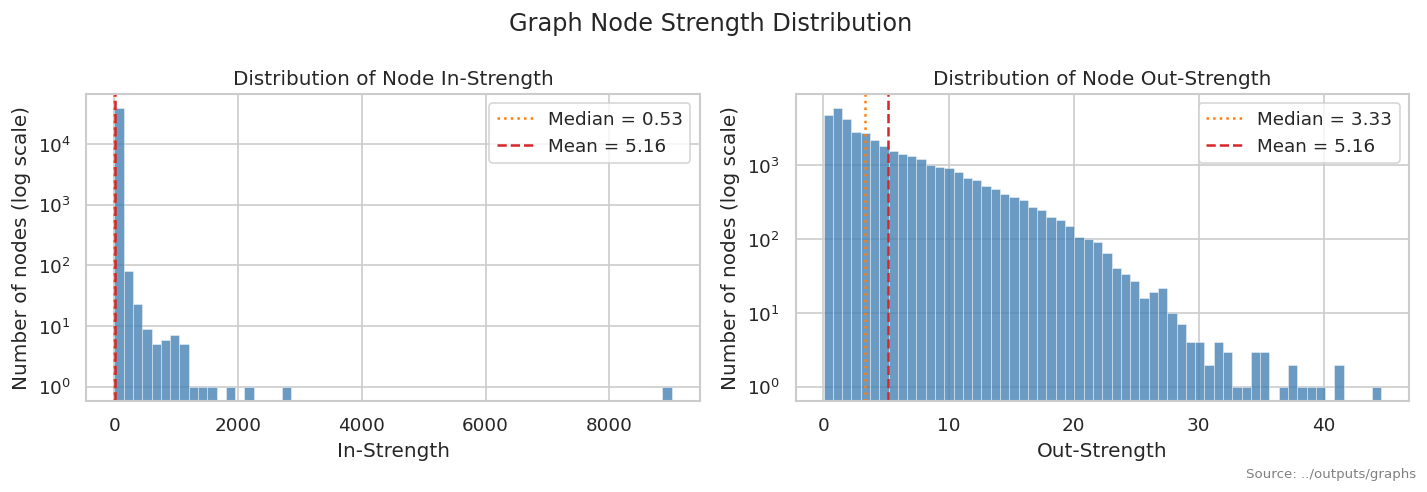

Nodes: 39,180  |  Edges: 6,205,788
in_strength: mean=5.16, median=0.53, max=9008.19
out_strength: mean=5.16, median=3.33, max=44.56


In [12]:
in_str  = dict(G.in_degree(weight='weight'))
out_str = dict(G.out_degree(weight='weight'))

strength_df = pd.DataFrame({
    'product_idx':  list(G.nodes()),
    'in_strength':  [in_str.get(n, 0.0)  for n in G.nodes()],
    'out_strength': [out_str.get(n, 0.0) for n in G.nodes()],
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['in_strength', 'out_strength'], ['In-Strength', 'Out-Strength']):
    data = strength_df[col]
    ax.hist(data[data > 0], bins=60, edgecolor='white', linewidth=0.3, color='steelblue', alpha=0.8)
    ax.set_yscale('log')
    ax.axvline(data.median(), color='tab:orange', linestyle=':',  linewidth=1.5,
               label=f'Median = {data.median():.2f}')
    ax.axvline(data.mean(),   color='tab:red',    linestyle='--', linewidth=1.5,
               label=f'Mean = {data.mean():.2f}')
    ax.set_xlabel(title)
    ax.set_ylabel('Number of nodes (log scale)')
    ax.set_title(f'Distribution of Node {title}')
    ax.legend()

fig.suptitle('Graph Node Strength Distribution')
fig.text(0.99, 0.01, f'Source: {GRAPH_DIR}', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

print(f'Nodes: {G.number_of_nodes():,}  |  Edges: {G.number_of_edges():,}')
for col in ['in_strength', 'out_strength']:
    s = strength_df[col]
    print(f'{col}: mean={s.mean():.2f}, median={s.median():.2f}, max={s.max():.2f}')

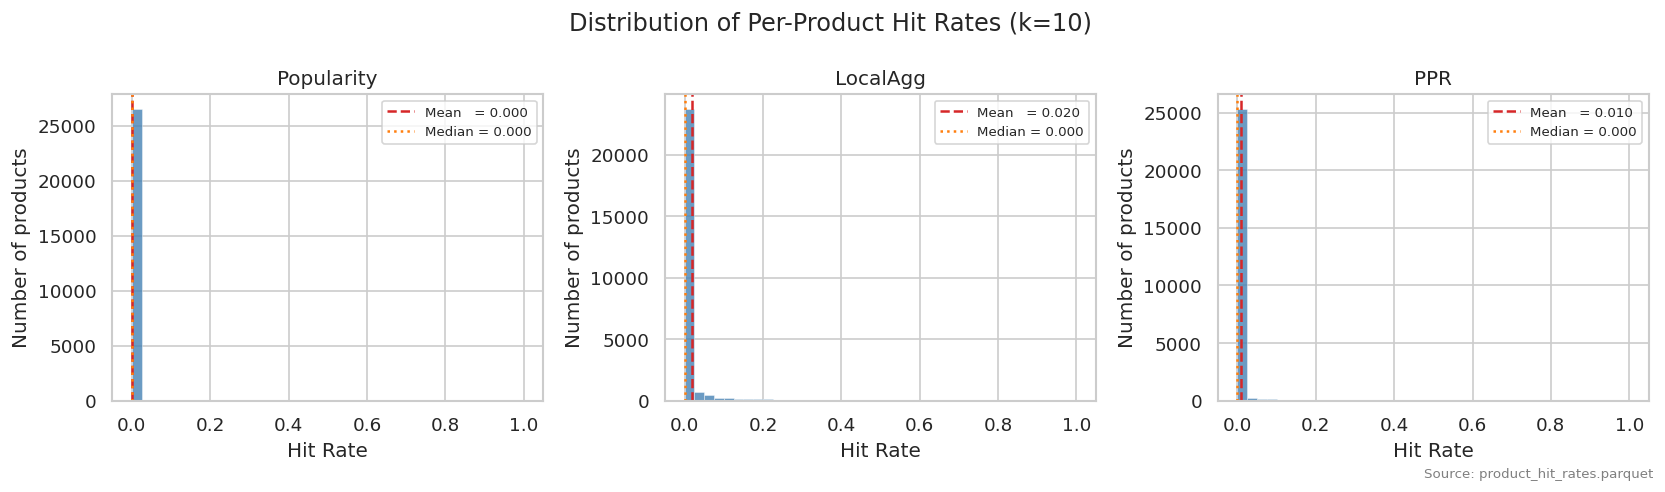

,count,mean,std,min,25%,50%,75%,max
LocalAgg,26579.0,0.0196,0.0833,0.0,0.0,0.0,0.0,1.0
Popularity,26579.0,0.0004,0.0195,0.0,0.0,0.0,0.0,1.0
PPR,26579.0,0.0101,0.0681,0.0,0.0,0.0,0.0,1.0


In [13]:
hit_rates = pd.read_parquet(HIT_RATES_PATH)

k_ref = 10
hr_k  = hit_rates[hit_rates['k'] == k_ref]

fig, axes = plt.subplots(1, len(METHOD_ORDER), figsize=(14, 4), sharey=False)
for ax, method in zip(axes, METHOD_ORDER):
    data = hr_k[hr_k['method'] == method]['hit_rate']
    ax.hist(data, bins=40, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(),   color='tab:red',    linestyle='--', linewidth=1.5,
               label=f'Mean   = {data.mean():.3f}')
    ax.axvline(data.median(), color='tab:orange', linestyle=':',  linewidth=1.5,
               label=f'Median = {data.median():.3f}')
    ax.set_xlabel('Hit Rate')
    ax.set_ylabel('Number of products')
    ax.set_title(METHOD_LABELS[method])
    ax.legend(fontsize=8)

fig.suptitle(f'Distribution of Per-Product Hit Rates (k={k_ref})')
fig.text(0.99, 0.01, 'Source: product_hit_rates.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

stats = hr_k.groupby('method')['hit_rate'].describe().round(4)
stats.index = [METHOD_LABELS.get(m, m) for m in stats.index]
display(stats)

## 11. Hit Rate vs Graph Strength

Relação entre a força do nó no grafo e sua hit rate individual. Produtos com alta in-strength são
alvos frequentes de arestas e tendem a receber scores mais altos dos dois métodos baseados no grafo.

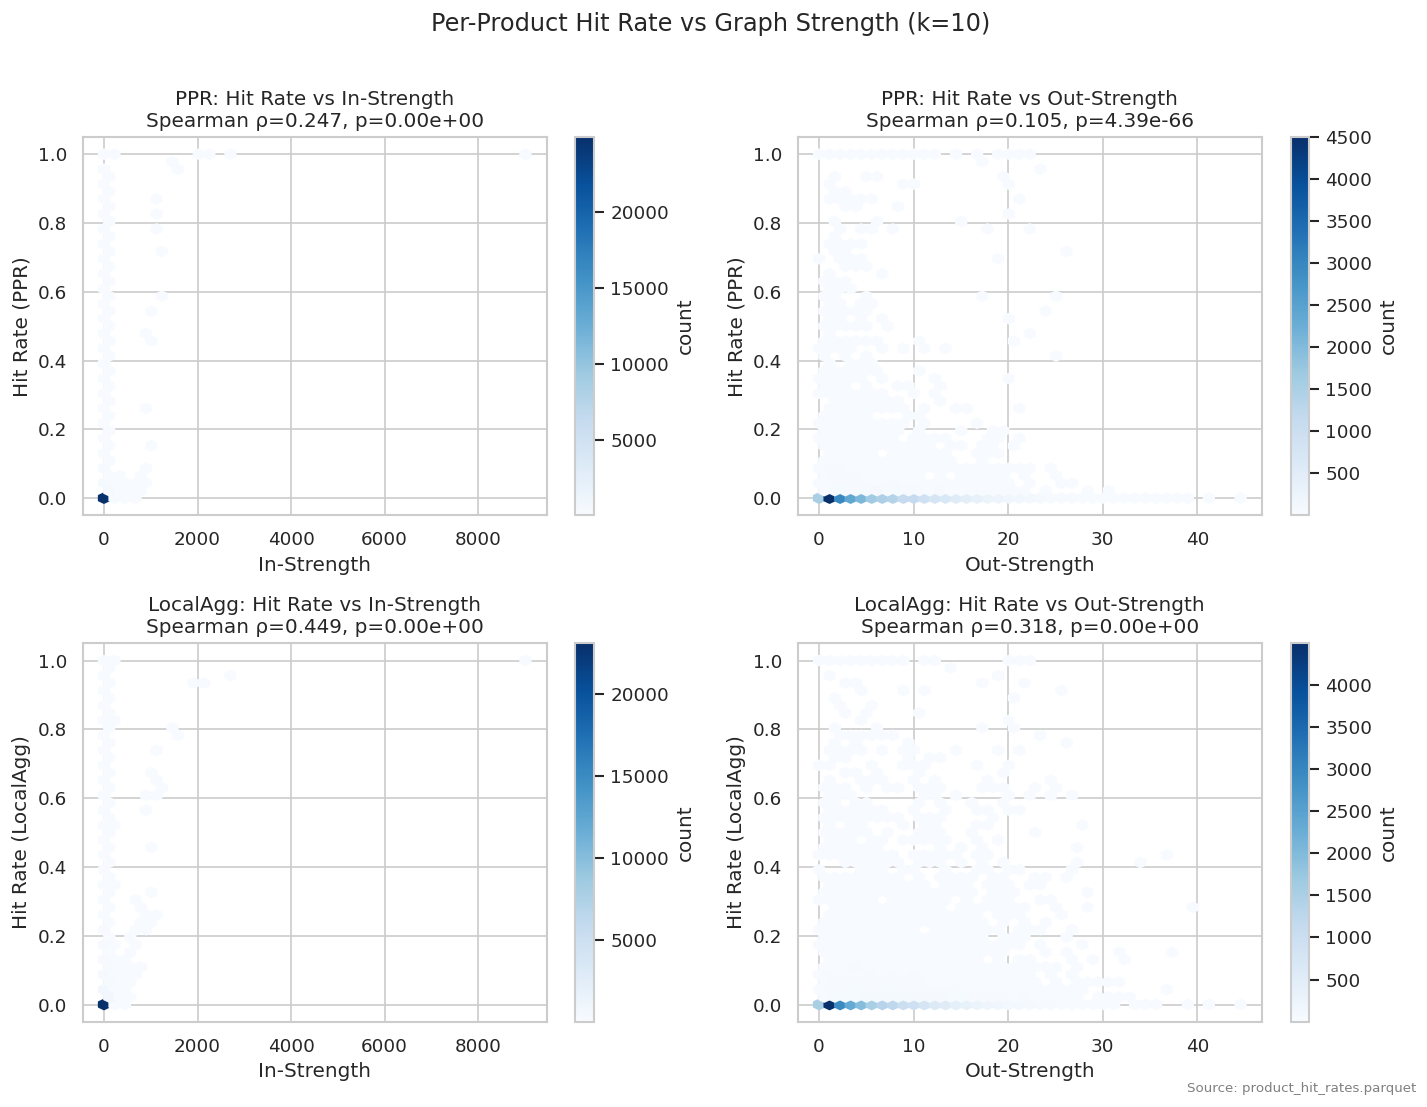

In [14]:
hr_wide = (
    hr_k[hr_k['method'].isin(['ppr', 'local_agg'])]
    .pivot(index='product_idx', columns='method', values='hit_rate')
    .rename(columns={'ppr': 'hit_rate_ppr', 'local_agg': 'hit_rate_local_agg'})
    .reset_index()
    .merge(strength_df, on='product_idx')
    .dropna()
)

combos = [
    ('hit_rate_ppr',       'in_strength',  'PPR',      'In-Strength'),
    ('hit_rate_ppr',       'out_strength', 'PPR',      'Out-Strength'),
    ('hit_rate_local_agg', 'in_strength',  'LocalAgg', 'In-Strength'),
    ('hit_rate_local_agg', 'out_strength', 'LocalAgg', 'Out-Strength'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (y_col, x_col, method_label, x_label) in zip(axes.flat, combos):
    x = hr_wide[x_col].values
    y = hr_wide[y_col].values
    hb = ax.hexbin(x, y, gridsize=40, mincnt=1, cmap='Blues')
    plt.colorbar(hb, ax=ax, label='count')
    rho, p = spearmanr(x, y)
    ax.set_xlabel(x_label)
    ax.set_ylabel(f'Hit Rate ({method_label})')
    ax.set_title(f'{method_label}: Hit Rate vs {x_label}\nSpearman ρ={rho:.3f}, p={p:.2e}')

fig.suptitle(f'Per-Product Hit Rate vs Graph Strength (k={k_ref})', y=1.01)
fig.text(0.99, 0.01, 'Source: product_hit_rates.parquet', ha='right', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

## 12. Key Findings

### Contexto da avaliação
- As métricas são **condicionais ao grafo**: produtos do teste ausentes do grafo (29,2%) são excluídos
  do numerador e do denominador. O recall condicional é ~41% mais alto que o recall real.
  Usar sempre **TRUE RECALL@k** (seção 4) ao comunicar resultados externamente.

### Ranking dos métodos
- **LocalAgg > PPR > Popularity** em todos os valores de k e frações observadas.
- LocalAgg supera Popularity em ~+0,05 Recall@10 (n_obs = 50%), confirmando que a estrutura
  de co-ocorrência carrega sinal além da frequência global.
- PPR supera Popularity mas fica abaixo do LocalAgg. Com α=0,85, o PPR atribui 85% da massa
  aos seeds a cada passo — tornando-o próximo do LocalAgg por construção.
  **O resultado LocalAgg > PPR pode ser sensível a α**; uma varredura é necessária antes de
  concluir que propagação multi-hop é inferior neste grafo.

### Significância estatística
- Com ~45 mil cestas e testes de Wilcoxon emparelhados, todos os ganhos são
  estatisticamente significativos (p ≪ 0.05).
- O que importa operacionalmente é `mean_Δrecall` (tamanho de efeito), não o p-valor —
  qualquer Δ > 0,001 resulta em p ≈ 0 com este n.

### Efeito da fração observada
- O recall condicional é **praticamente constante** entre 25% e 75% de observação
  (variação < 0,002 em Recall@10 para todos os métodos).
- Isso **não** significa que mais contexto não ajuda — significa que o Recall@k não captura
  essa diferença: hits e `|hidden|` diminuem na mesma proporção.
- A **basket_coverage@k** (hits / basket_size, seção 5b) evidencia que os métodos não recuperam
  uma fração maior da cesta com mais contexto: a cobertura absoluta decresce monotonicamente.
- O ganho de LocalAgg sobre Popularity é estável (~0,046–0,049 em Δrecall@10) entre 25% e 75%,
  indicando que seeds adicionais não amplificam a vantagem do grafo.

### Efeito do tamanho da cesta
- Cestas maiores (21+ itens) produzem recall mais estável e favorável para os métodos baseados em grafo.
- Cestas muito pequenas (2–3 itens) têm alta variância: recall binomial (0 ou 1) com 1 item hidden.

### Análise por produto
- Hit rate é positivamente correlacionada com in-strength do nó (Spearman ρ > 0 para LocalAgg e PPR):
  o grafo não elimina o viés de popularidade, apenas o redistribui via arestas de co-ocorrência.
- Produtos de nicho (baixa in-strength) têm hit rate próxima de zero em todos os métodos.

### Limitações e próximos passos
- **NDCG@k** não é computável sem informação de posição dos hits. Adicionar a posição ao output
  do experimento permitiria avaliar qualidade de ranking, não só cobertura.
- Uma varredura de **α** (PPR) pode alterar o ranking PPR vs. LocalAgg.
- Para testar se os métodos exploram contexto, redesenhar o protocolo com `|hidden|` fixo
  (ex.: ocultar sempre k itens, independente do tamanho da cesta).